In [1]:
# =============================================================================
# STEP 4 – Alternative Clustering-Methoden zu K-Means
# Methoden: (1) Agglomerative Hierarchical Clustering
#            (2) Gaussian Mixture Model (GMM)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
# =============================================================================
# A. Daten laden & vorbereiten (identisch zu Original-Notebook)
# =============================================================================

df3 = pd.read_csv(
    r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\01_data\processed\STEP2und3_df_kundensegmentierung_regelbasiert.csv"
)

# Restmenge: nur Nutzer ohne regelbasiertes Segment
df_ml = df3[df3["segment_rule"].isna()].copy()

print(f"df_ml Shape: {df_ml.shape}")

# Features vorbereiten
bool_cols = df_ml.select_dtypes(include=["bool"]).columns.tolist()
num_cols = df_ml.select_dtypes(include=["number"]).columns.tolist()

# user_id und segment_rule entfernen
drop_cols = ["user_id", "segment_rule"]
num_feature_cols = [c for c in num_cols if c not in drop_cols]

# Bool → int (0/1)
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

# PowerTransformer auf numerische Features (ohne Bools)
pt = PowerTransformer(method="yeo-johnson")
df_pt = df_ml[num_feature_cols].copy()
df_pt[num_feature_cols] = pt.fit_transform(df_pt[num_feature_cols])

# Bool-Features anhängen
df_transformed = pd.concat([df_pt, df_ml[bool_cols]], axis=1)

# StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_transformed),
    columns=df_transformed.columns,
    index=df_transformed.index
)

print("Preprocessing abgeschlossen. df_scaled Shape:", df_scaled.shape)

X = df_scaled.values  # Numpy-Array für Clustering

df_ml Shape: (4371, 30)
Preprocessing abgeschlossen. df_scaled Shape: (4371, 28)



METHODE 1: Agglomerative Hierarchical Clustering


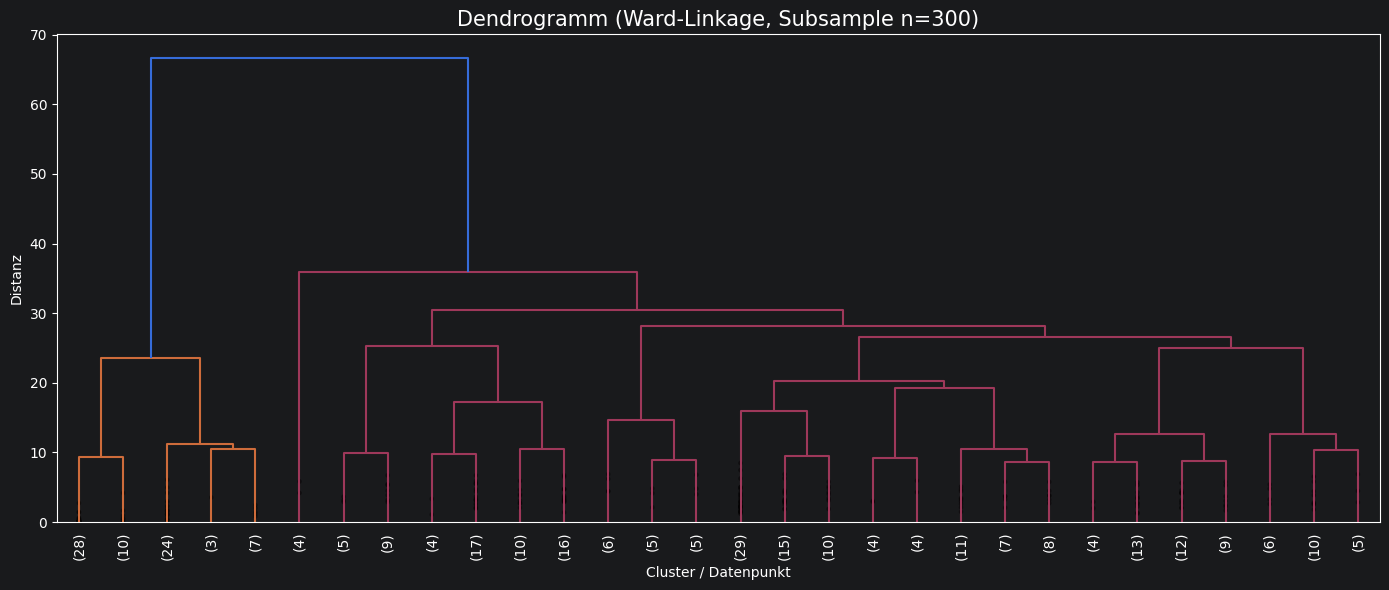

In [8]:
# =============================================================================
# B. METHODE 1: Agglomerative Hierarchical Clustering
# =============================================================================
# Vorteile gegenüber K-Means:
# - Kein Zentroid notwendig → robuster bei nicht-kugelförmigen Clustern
# - Dendrogramm gibt visuellen Hinweis auf optimale Clusteranzahl
# - Kein Zufallsfaktor (deterministisch, kein random_state nötig)
# =============================================================================

print("\n" + "="*60)
print("METHODE 1: Agglomerative Hierarchical Clustering")
print("="*60)

# ── B1. Dendrogramm (auf Subsample, da n=4371 zu groß für vollständiges Dendrogramm)
sample_idx = np.random.default_rng(42).choice(len(X), size=300, replace=False)
X_sample = X[sample_idx]

linkage_matrix = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Dendrogramm (Ward-Linkage, Subsample n=300)", fontsize=15)
plt.xlabel("Cluster / Datenpunkt")
plt.ylabel("Distanz")
plt.tight_layout()
plt.show()



Silhouette-Scores (Agglomerative, Ward):
  k=2: Silhouette = 0.2674
  k=3: Silhouette = 0.1878
  k=4: Silhouette = 0.1865
  k=5: Silhouette = 0.2038
  k=6: Silhouette = 0.2128
  k=7: Silhouette = 0.2270
  k=8: Silhouette = 0.2143
  k=9: Silhouette = 0.2056
  k=10: Silhouette = 0.2148


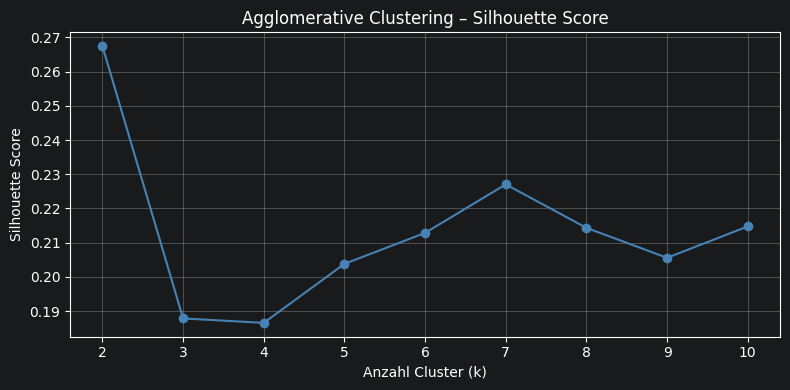

In [9]:
# ── B2. Silhouette-Score für k = 2..10
print("\nSilhouette-Scores (Agglomerative, Ward):")
agg_sil_scores = {}

for k in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=2000, random_state=42)
    agg_sil_scores[k] = sil
    print(f"  k={k}: Silhouette = {sil:.4f}")

# Plot Silhouette
plt.figure(figsize=(8, 4))
plt.plot(list(agg_sil_scores.keys()), list(agg_sil_scores.values()), marker="o", color="steelblue")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Agglomerative Clustering – Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# ── B3. Finales Agglomerative Clustering mit optimaler k
# k_agg = max(agg_sil_scores, key=agg_sil_scores.get)
k_agg = 6

print(f"\nOptimale Clusteranzahl (Agglomerative): k={k_agg}")

agg_final = AgglomerativeClustering(n_clusters=k_agg, linkage="ward")
agg_labels = agg_final.fit_predict(X)

df_ml["cluster_agg"] = agg_labels

# Cluster-Größen
print("\nClustergrößen (Agglomerative):")
print(df_ml["cluster_agg"].value_counts().sort_index())



Optimale Clusteranzahl (Agglomerative): k=6

Clustergrößen (Agglomerative):
cluster_agg
0    2058
1     836
2     230
3     990
4     226
5      31
Name: count, dtype: int64


In [17]:
# ── B4. Cluster-Profile
cluster_profile_agg = df_ml.groupby("cluster_agg").mean(numeric_only=True)
print("\nCluster-Mittelwerte (Agglomerative):")
print(cluster_profile_agg.T)



Cluster-Mittelwerte (Agglomerative):
cluster_agg                                    0              1  \
sessions_ttl                            8.206997       8.199761   
clicks_avg                             18.620903      12.818228   
cancellations_ttl                       0.139942       0.081340   
flights_booked_ttl                      2.206997       0.000000   
hotels_booked_ttl                       2.297376       0.577751   
nightsPerTrip_avg                       3.382604       3.571970   
lead_time_flight_days_avg              11.831268       0.000000   
lead_time_flight_days_std               3.449544       0.000000   
business_weekday_rate                   0.432054       0.000000   
hotel_discount_proportion_avg           0.130871       0.097687   
hotel_discount_amount_avg               0.030584       0.012350   
winter_escape_rate                      0.000162       0.000000   
recency_days_flight                   430.182702       0.000000   
unique_destinations_coun

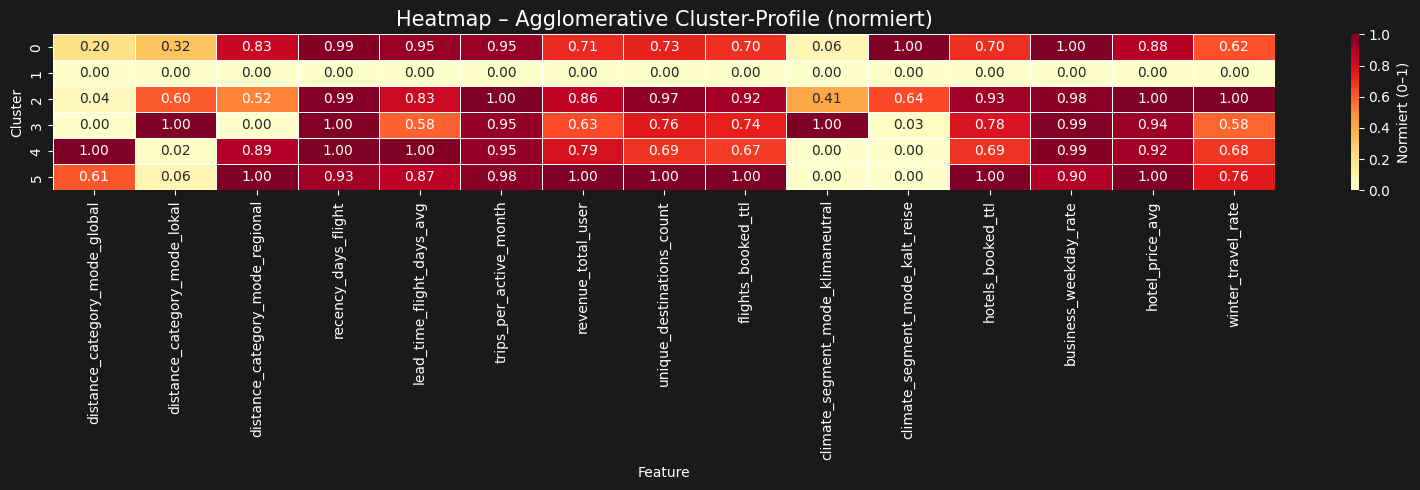

In [18]:
# ── B5. Heatmap
top_features = [
    "distance_category_mode_global", "distance_category_mode_lokal",
    "distance_category_mode_regional", "recency_days_flight",
    "lead_time_flight_days_avg", "trips_per_active_month",
    "revenue_total_user", "unique_destinations_count",
    "flights_booked_ttl", "climate_segment_mode_klimaneutral",
    "climate_segment_mode_kalt_reise", "hotels_booked_ttl",
    "business_weekday_rate", "hotel_price_avg", "winter_travel_rate"
]

# Nur Features, die im df_ml vorhanden sind
top_features = [f for f in top_features if f in df_ml.columns]

cluster_means_agg = df_ml.groupby("cluster_agg")[top_features].mean()
cluster_means_norm = (cluster_means_agg - cluster_means_agg.min()) / \
                     (cluster_means_agg.max() - cluster_means_agg.min() + 1e-9)

plt.figure(figsize=(16, 5))
sns.heatmap(cluster_means_norm, annot=True, cmap="YlOrRd", fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Normiert (0–1)"})
plt.title("Heatmap – Agglomerative Cluster-Profile (normiert)", fontsize=15)
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [19]:
# ── B6. Qualitätsmetriken
sil_agg  = silhouette_score(X, agg_labels, sample_size=2000, random_state=42)
db_agg   = davies_bouldin_score(X, agg_labels)
ch_agg   = calinski_harabasz_score(X, agg_labels)

print(f"\nQualitätsmetriken Agglomerative (k={k_agg}):")
print(f"  Silhouette Score      : {sil_agg:.4f}  (höher = besser, max=1)")
print(f"  Davies-Bouldin Index  : {db_agg:.4f}  (niedriger = besser)")
print(f"  Calinski-Harabasz     : {ch_agg:.1f}  (höher = besser)")




Qualitätsmetriken Agglomerative (k=6):
  Silhouette Score      : 0.2128  (höher = besser, max=1)
  Davies-Bouldin Index  : 1.6257  (niedriger = besser)
  Calinski-Harabasz     : 640.2  (höher = besser)



METHODE 2: Gaussian Mixture Model (GMM)
  k=2: BIC=-60942.6, AIC=-66489.2
  k=3: BIC=-202449.2, AIC=-210772.3
  k=4: BIC=-262134.3, AIC=-273233.9
  k=5: BIC=-289442.2, AIC=-303318.3
  k=6: BIC=-319804.3, AIC=-336456.9
  k=7: BIC=-344488.1, AIC=-363917.2
  k=8: BIC=-367239.8, AIC=-389445.4
  k=9: BIC=-377530.6, AIC=-402512.6
  k=10: BIC=-394794.1, AIC=-422552.6


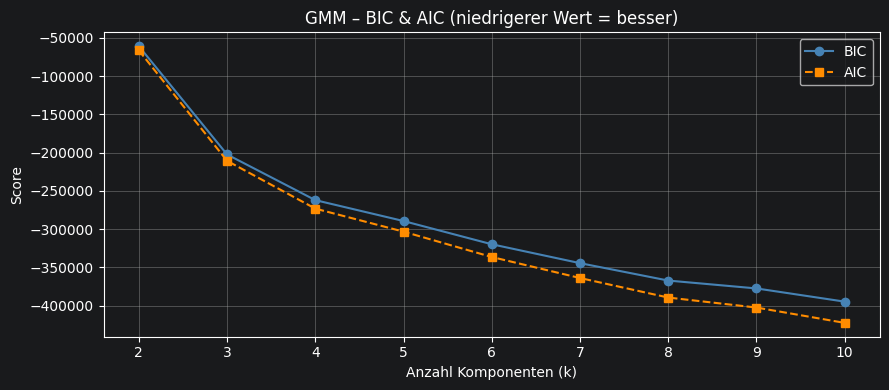

In [20]:
# =============================================================================
# C. METHODE 2: Gaussian Mixture Model (GMM)
# =============================================================================
# Vorteile gegenüber K-Means:
# - Soft-Clustering: jeder Nutzer erhält Wahrscheinlichkeit pro Cluster
# - Modelliert elliptische / nicht-sphärische Cluster
# - BIC/AIC als statistisch fundiertes Kriterium für optimale k
# =============================================================================

print("\n" + "="*60)
print("METHODE 2: Gaussian Mixture Model (GMM)")
print("="*60)

# ── C1. BIC & AIC zur Bestimmung der optimalen Clusteranzahl
bic_scores = []
aic_scores = []
K_range = range(2, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          random_state=42, max_iter=200, n_init=5)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))
    print(f"  k={k}: BIC={gmm.bic(X):.1f}, AIC={gmm.aic(X):.1f}")

# Plot BIC & AIC
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range), bic_scores, marker="o", label="BIC", color="steelblue")
ax.plot(list(K_range), aic_scores, marker="s", label="AIC", color="darkorange", linestyle="--")
ax.set_xlabel("Anzahl Komponenten (k)")
ax.set_ylabel("Score")
ax.set_title("GMM – BIC & AIC (niedrigerer Wert = besser)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# ── C2. Optimale k nach BIC (Minimum)
k_gmm = list(K_range)[np.argmin(bic_scores)]
print(f"\nOptimale Clusteranzahl nach BIC (GMM): k={k_gmm}")



Optimale Clusteranzahl nach BIC (GMM): k=10


In [22]:
# ── C3. Finales GMM
gmm_final = GaussianMixture(n_components=k_gmm, covariance_type="full",
                             random_state=42, max_iter=200, n_init=10)
gmm_final.fit(X)
gmm_labels = gmm_final.predict(X)
gmm_proba  = gmm_final.predict_proba(X)  # Soft-Assignments

df_ml["cluster_gmm"] = gmm_labels

# Cluster-Größen
print("\nClustergrößen (GMM):")
print(df_ml["cluster_gmm"].value_counts().sort_index())



Clustergrößen (GMM):
cluster_gmm
0    263
1    643
2    387
3    390
4    501
5    494
6    207
7    885
8    152
9    449
Name: count, dtype: int64



Durchschnittliche Zuordnungssicherheit: 1.000
Anteil Nutzer mit Konfidenz > 0.8: 100.0%


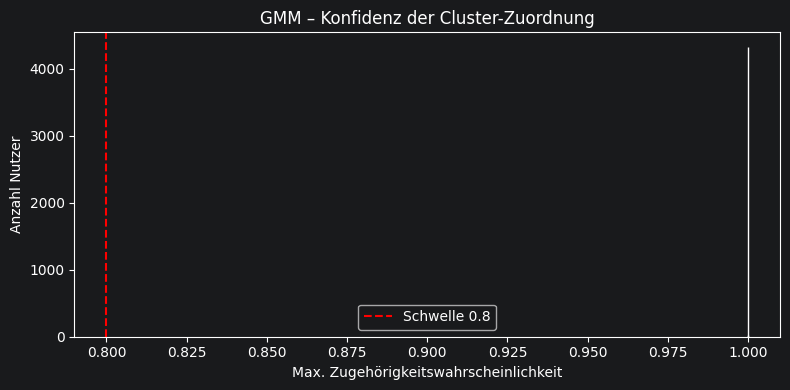

In [23]:
# ── C4. Unsicherheits-Score: max. Zugehörigkeitswahrscheinlichkeit pro Nutzer
df_ml["gmm_confidence"] = gmm_proba.max(axis=1)
print(f"\nDurchschnittliche Zuordnungssicherheit: {df_ml['gmm_confidence'].mean():.3f}")
print(f"Anteil Nutzer mit Konfidenz > 0.8: {(df_ml['gmm_confidence'] > 0.8).mean()*100:.1f}%")

# Plot Konfidenz-Histogramm
plt.figure(figsize=(8, 4))
plt.hist(df_ml["gmm_confidence"], bins=30, color="darkorange", edgecolor="white")
plt.xlabel("Max. Zugehörigkeitswahrscheinlichkeit")
plt.ylabel("Anzahl Nutzer")
plt.title("GMM – Konfidenz der Cluster-Zuordnung")
plt.axvline(0.8, color="red", linestyle="--", label="Schwelle 0.8")
plt.legend()
plt.tight_layout()
plt.show()


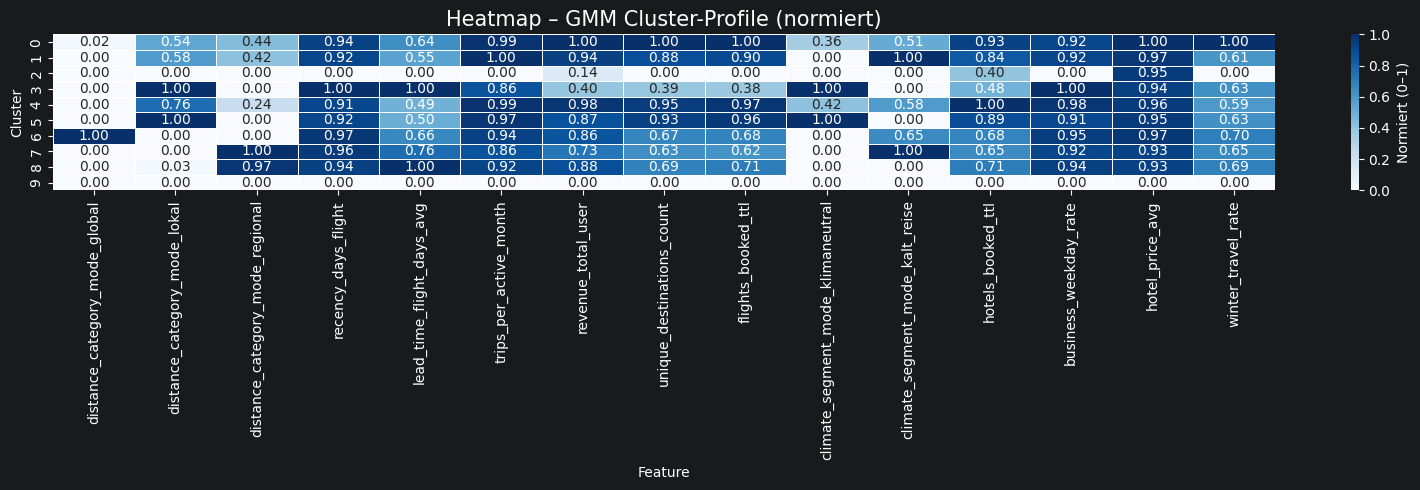

In [24]:
# ── C5. Cluster-Profile (Heatmap)
cluster_means_gmm = df_ml.groupby("cluster_gmm")[top_features].mean()
cluster_means_gmm_norm = (cluster_means_gmm - cluster_means_gmm.min()) / \
                         (cluster_means_gmm.max() - cluster_means_gmm.min() + 1e-9)

plt.figure(figsize=(16, 5))
sns.heatmap(cluster_means_gmm_norm, annot=True, cmap="Blues", fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Normiert (0–1)"})
plt.title("Heatmap – GMM Cluster-Profile (normiert)", fontsize=15)
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [25]:
# ── C6. Qualitätsmetriken
sil_gmm = silhouette_score(X, gmm_labels, sample_size=2000, random_state=42)
db_gmm  = davies_bouldin_score(X, gmm_labels)
ch_gmm  = calinski_harabasz_score(X, gmm_labels)

print(f"\nQualitätsmetriken GMM (k={k_gmm}):")
print(f"  Silhouette Score      : {sil_gmm:.4f}  (höher = besser, max=1)")
print(f"  Davies-Bouldin Index  : {db_gmm:.4f}  (niedriger = besser)")
print(f"  Calinski-Harabasz     : {ch_gmm:.1f}  (höher = besser)")




Qualitätsmetriken GMM (k=10):
  Silhouette Score      : 0.1735  (höher = besser, max=1)
  Davies-Bouldin Index  : 1.9144  (niedriger = besser)
  Calinski-Harabasz     : 521.9  (höher = besser)


In [26]:
# =============================================================================
# D. Methodenvergleich (Agglomerative vs. GMM vs. K-Means Referenz)
# =============================================================================

print("\n" + "="*60)
print("METHODENVERGLEICH")
print("="*60)

comparison = pd.DataFrame({
    "Methode": [
        f"Agglomerative (k={k_agg})",
        f"GMM           (k={k_gmm})",
        "K-Means       (k=4)  [Referenz]"
    ],
    "Silhouette ↑": [sil_agg, sil_gmm, "→ aus Original-Notebook"],
    "Davies-Bouldin ↓": [f"{db_agg:.4f}", f"{db_gmm:.4f}", "→ aus Original-Notebook"],
    "Calinski-Harabasz ↑": [f"{ch_agg:.1f}", f"{ch_gmm:.1f}", "→ aus Original-Notebook"]
})
print(comparison.to_string(index=False))

print("""
Entscheidungshilfe:
  Agglomerative  → ideal wenn Cluster-Hierarchie wichtig; deterministisch
  GMM            → ideal wenn überlappende Cluster und Soft-Assignments gewünscht
  K-Means        → schnell, skalierbar, gut bei kugelförmigen Clustern
""")




METHODENVERGLEICH
                        Methode            Silhouette ↑        Davies-Bouldin ↓     Calinski-Harabasz ↑
            Agglomerative (k=6)                0.212849                  1.6257                   640.2
           GMM           (k=10)                0.173494                  1.9144                   521.9
K-Means       (k=4)  [Referenz] → aus Original-Notebook → aus Original-Notebook → aus Original-Notebook

Entscheidungshilfe:
  Agglomerative  → ideal wenn Cluster-Hierarchie wichtig; deterministisch
  GMM            → ideal wenn überlappende Cluster und Soft-Assignments gewünscht
  K-Means        → schnell, skalierbar, gut bei kugelförmigen Clustern



In [ ]:
# =============================================================================
# E. Beste Methode → segment_rule befüllen (analog Original)
# =============================================================================
# Beispiel: Agglomerative mit k=4 Cluster-Namen
# (anpassen nach Profilanalyse der Heatmap)

#cluster_to_name_agg = {
#    0: "ML_Cluster_0",
#    1: "ML_Cluster_1",
#    2: "ML_Cluster_2",
#    3: "ML_Cluster_3",
#}

# Nur befüllen wenn k_agg == 4, sonst generisch
#if k_agg == 4:
#    df_ml["segment_rule"] = df_ml["segment_rule"].fillna(
#        df_ml["cluster_agg"].map(cluster_to_name_agg)
#    )
#else:
#    df_ml["segment_rule"] = df_ml["segment_rule"].fillna(
#        df_ml["cluster_agg"].apply(lambda x: f"ML_Cluster_{x}")
#    )

#print("Finale Segmentverteilung (Agglomerative):")
#print(df_ml["segment_rule"].value_counts())